<a href="https://colab.research.google.com/github/AjaySreekumar47/japanese-credit-screening/blob/main/JapaneseCreditScoreScreener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Japanese Credit Screening Project

This project performs end-to-end analysis of the Japanese Credit Screening dataset from UCI.
It includes:
- Data loading and preprocessing
- Statistical analysis and visualization
- Credit risk modeling (including time-series and multivariate regression)
- Model evaluation and comparison
- Deployment preparation


In [ ]:
# Install required packages
!pip install seaborn joblib scikit-learn pandas numpy matplotlib statsmodels

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
import logging
import joblib
import datetime
import warnings
import requests
from pathlib import Path
from google.colab import drive

# Suppress warnings
warnings.filterwarnings('ignore')

# Mount Google Drive for saving results
drive.mount('/content/drive')

# Create output directory in Google Drive
output_dir = '/content/drive/MyDrive/japanese_credit_screening_outputs'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, 'eda'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'models'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'feature_importance'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'model_visualization'), exist_ok=True)

# Configure basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Download function for the dataset
def download_dataset():
    """Download the Japanese Credit Screening dataset from UCI Repository"""
    print("Downloading Japanese Credit Screening dataset...")

    data_dir = "/content"

    # Define URLs
    credit_data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"

    try:
        response = requests.get(credit_data_url)
        response.raise_for_status()

        with open(os.path.join(data_dir, "crx.data"), "wb") as f:
            f.write(response.content)

        print("Dataset downloaded successfully!")
        return os.path.join(data_dir, "crx.data")
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        return None

# DATA LOADING AND PREPROCESSING


Dataset downloaded successfully!

1. LOADING DATASET
-------------------
Dataset shape: (690, 16)

Data preview:
  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15  class
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  202.0    0      1
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g   43.0  560      1
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  280.0  824      1
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  100.0    3      1
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  120.0    0      1

Missing values per column:
A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
class     0
dtype: int64

Class distribution:
class
0    383
1    307
Name: count, dtype: int64


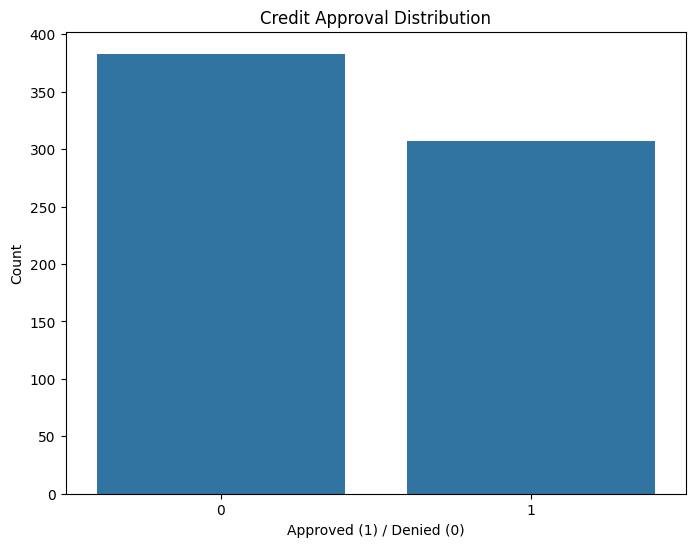


Categorical columns: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']
Numerical columns: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']


In [ ]:
# Download the dataset
data_path = download_dataset()

if not data_path:
    raise ValueError("Failed to download the dataset. Please check the URL.")

# Load the dataset
print("\n1. LOADING DATASET")
print("-------------------")

# Define column names based on the UCI documentation
column_names = [f'A{i}' for i in range(1, 16)] + ['class']

# Load the data
data = pd.read_csv(data_path, header=None, names=column_names, na_values='?')

# Convert class labels to binary (1 for '+' approved, 0 for '-' denied)
data['class'] = data['class'].map({'+': 1, '-': 0})

print(f"Dataset shape: {data.shape}")
print("\nData preview:")
print(data.head())

print("\nMissing values per column:")
print(data.isnull().sum())

print("\nClass distribution:")
class_counts = data['class'].value_counts()
print(class_counts)

# Plot class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=data)
plt.title('Credit Approval Distribution')
plt.xlabel('Approved (1) / Denied (0)')
plt.ylabel('Count')
plt.savefig(os.path.join(output_dir, 'eda', 'class_distribution.png'))
plt.show()

# Identify categorical and numerical columns
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variable from features list
if 'class' in num_cols:
    num_cols.remove('class')

print("\nCategorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# EXPLORATORY DATA ANALYSIS


2. EXPLORATORY DATA ANALYSIS
-----------------------------

Basic statistics for numerical columns:
               A2          A3          A8        A11          A14  \
count  678.000000  690.000000  690.000000  690.00000   677.000000   
mean    31.568171    4.758725    2.223406    2.40000   184.014771   
std     11.957862    4.978163    3.346513    4.86294   173.806768   
min     13.750000    0.000000    0.000000    0.00000     0.000000   
25%     22.602500    1.000000    0.165000    0.00000    75.000000   
50%     28.460000    2.750000    1.000000    0.00000   160.000000   
75%     38.230000    7.207500    2.625000    3.00000   276.000000   
max     80.250000   28.000000   28.500000   67.00000  2000.000000   

                 A15  
count     690.000000  
mean     1017.385507  
std      5210.102598  
min         0.000000  
25%         0.000000  
50%         5.000000  
75%       395.500000  
max    100000.000000  


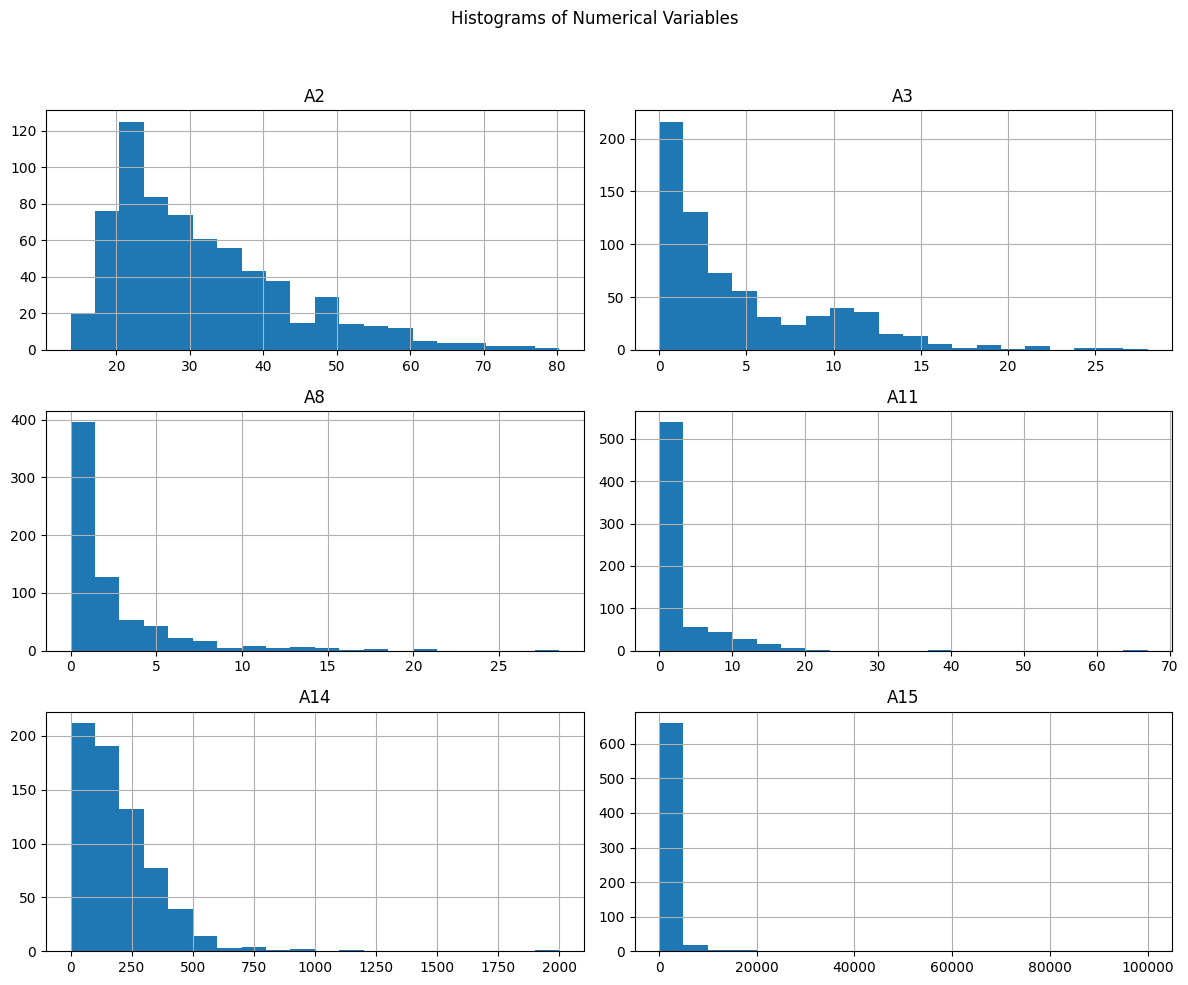

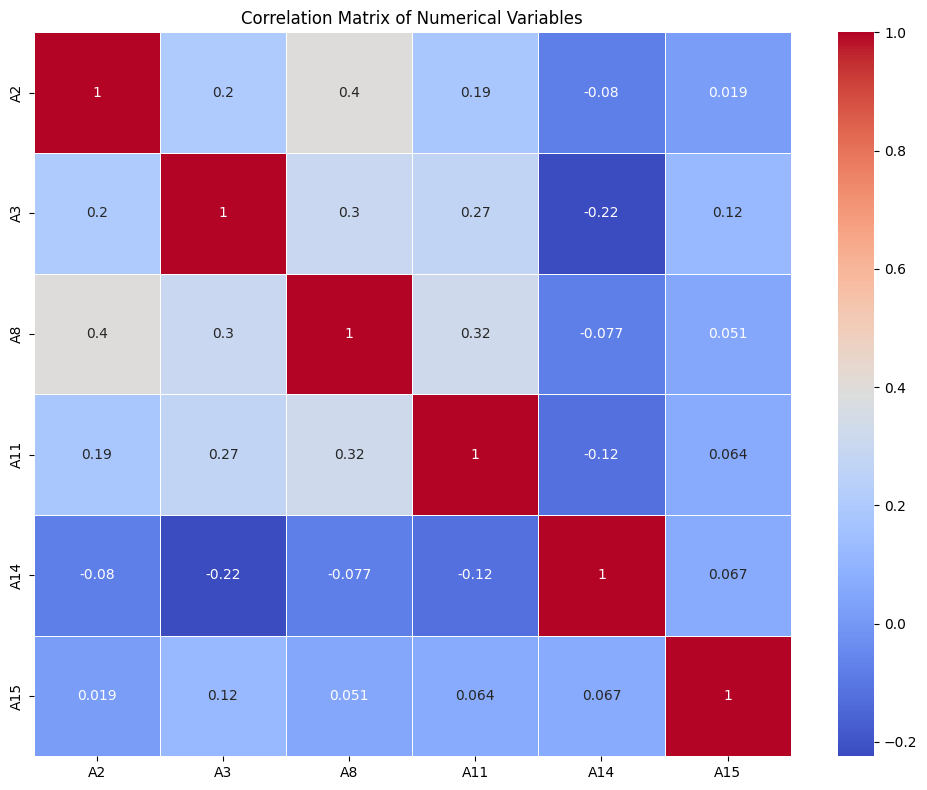

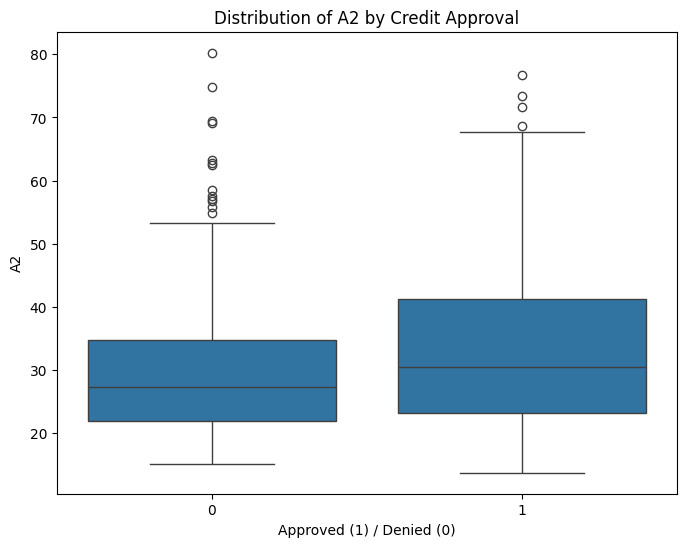

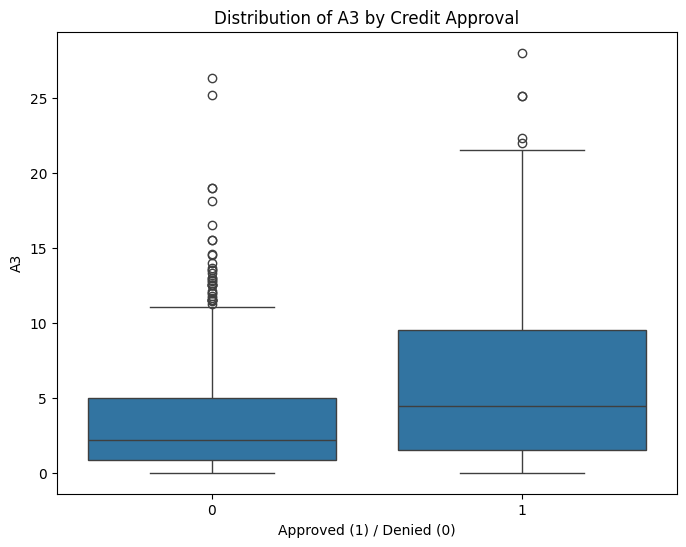

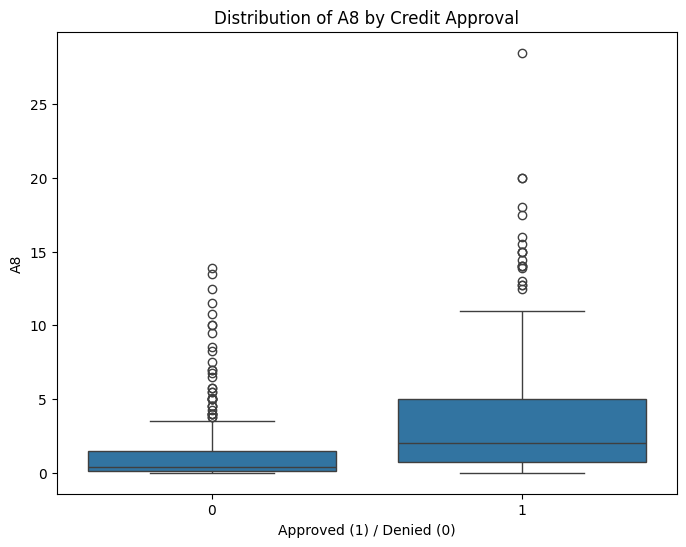

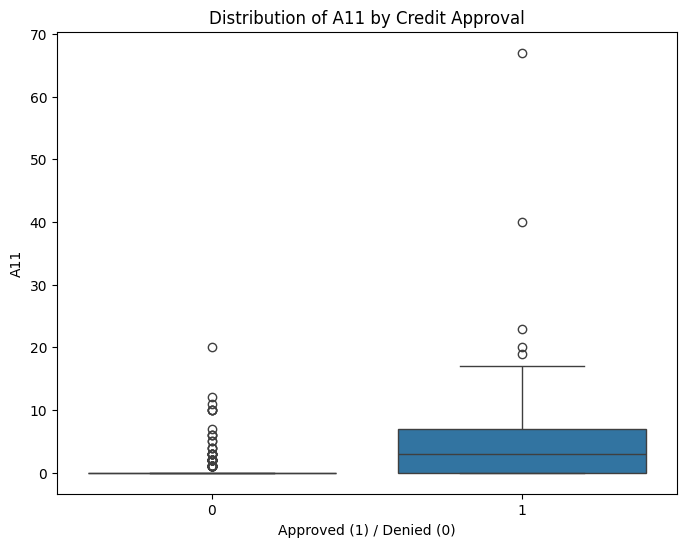

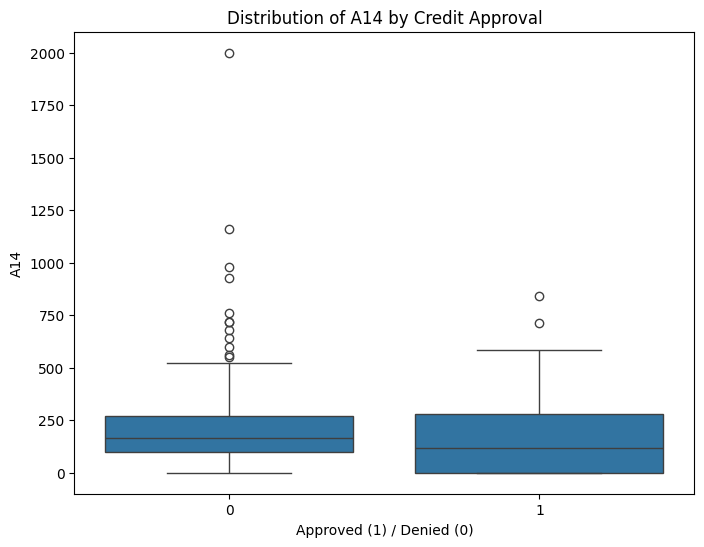

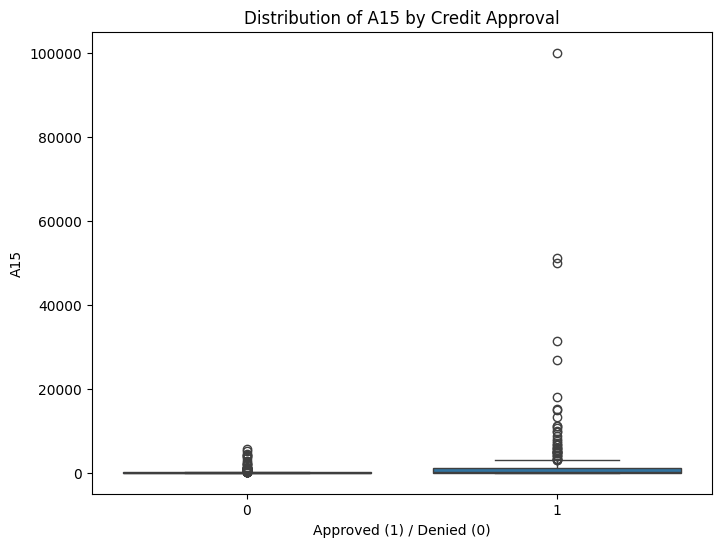

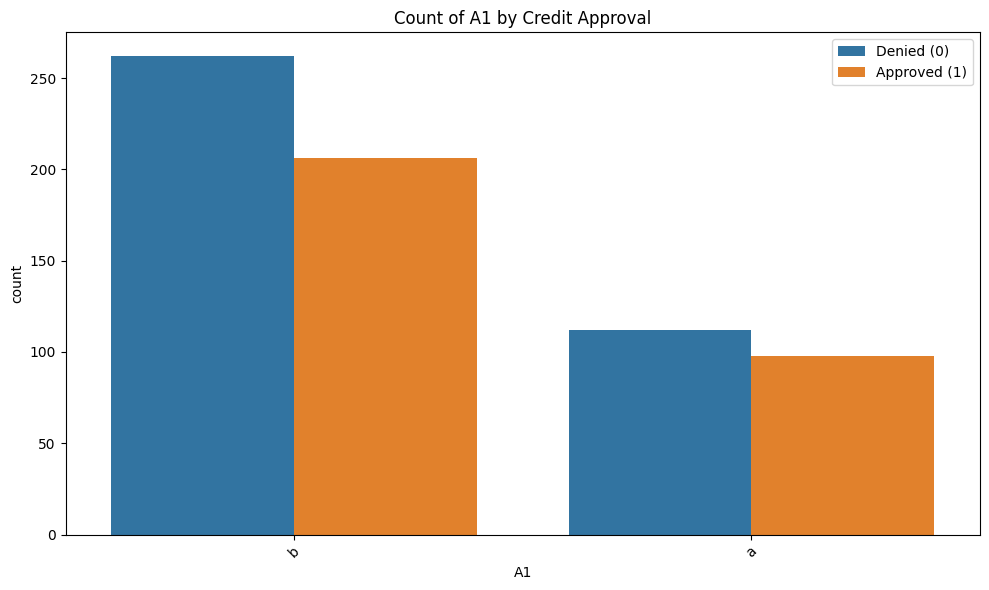

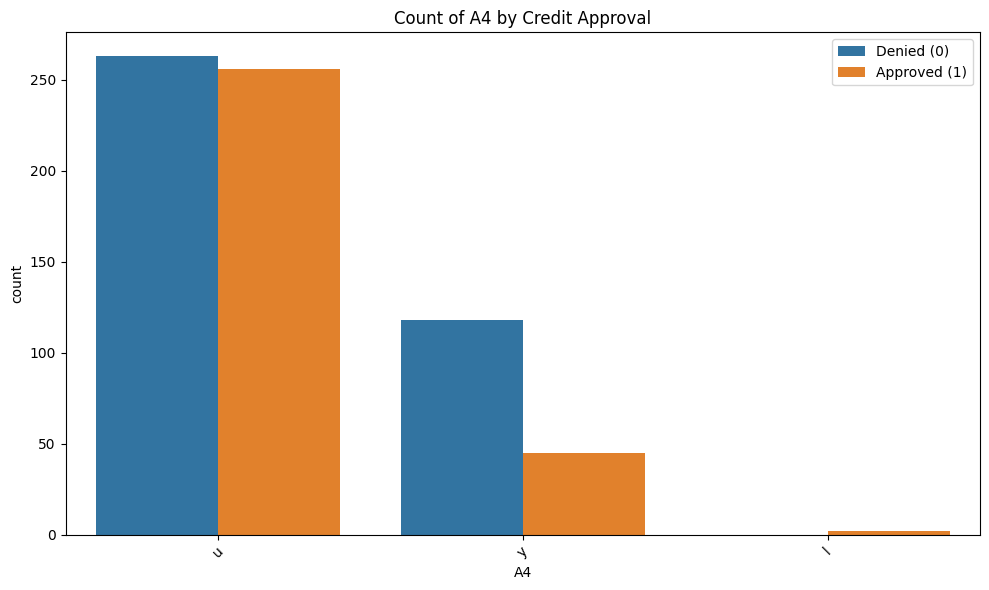

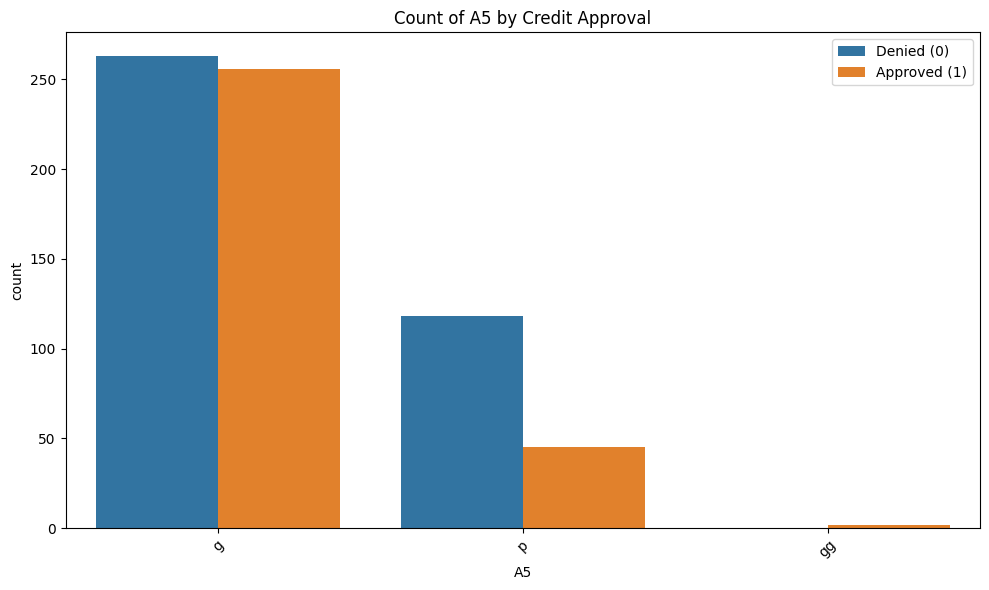

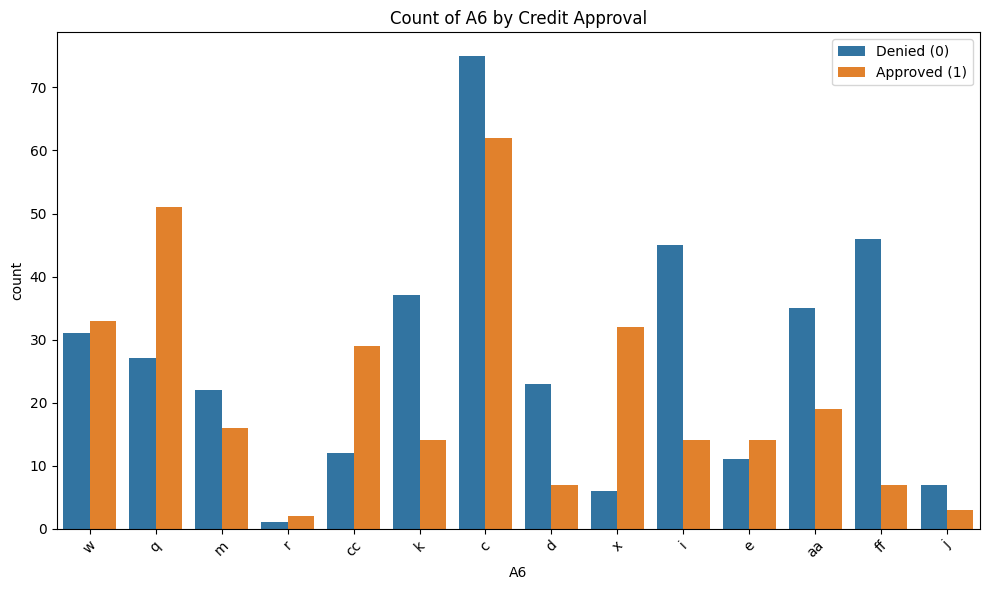

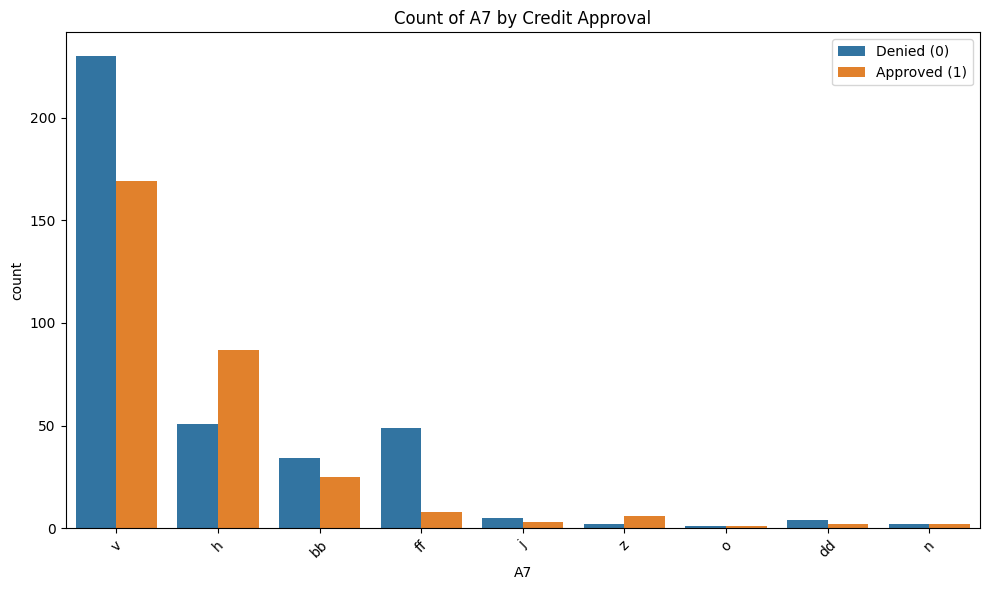

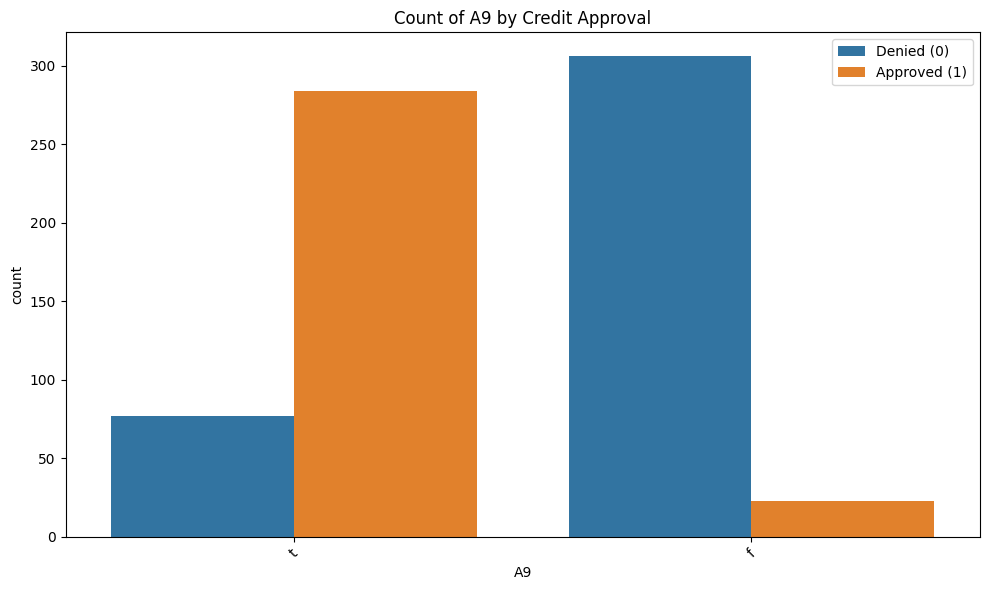

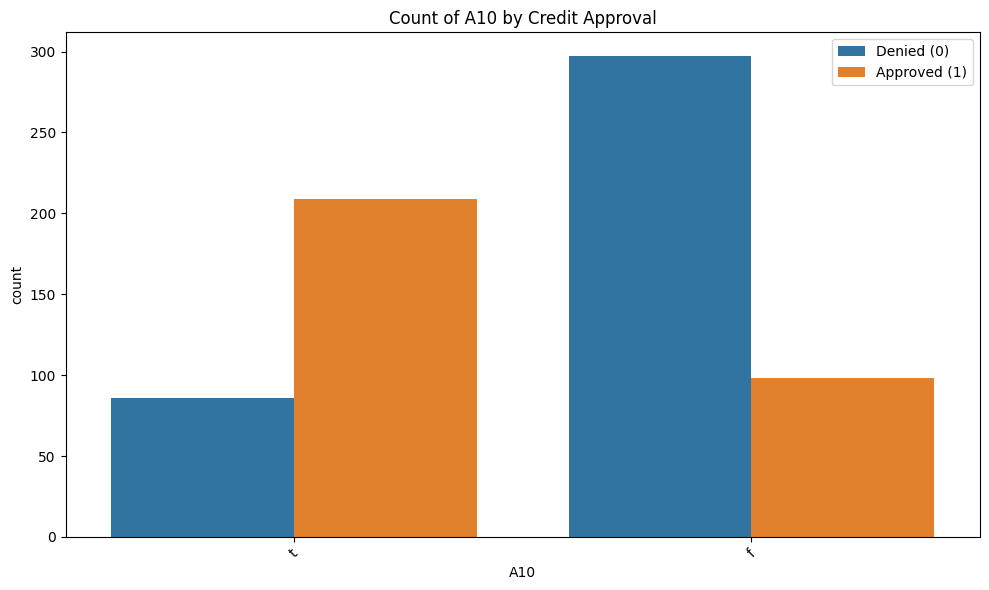

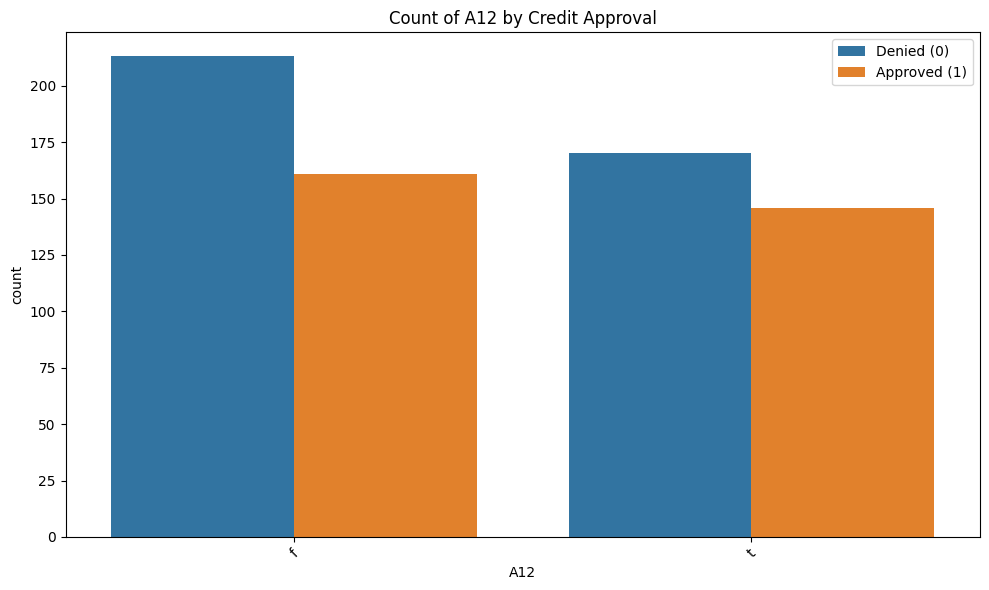

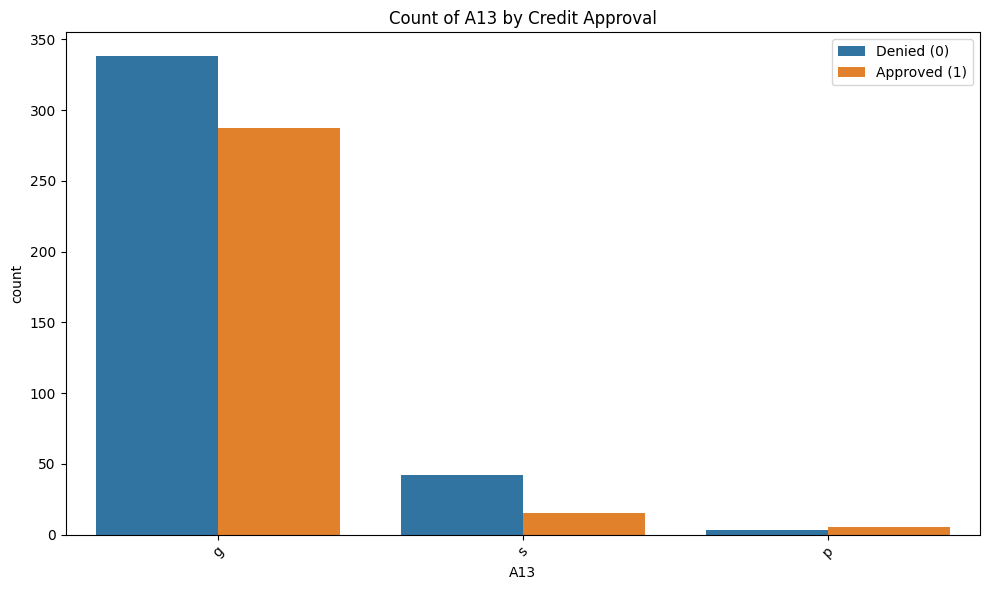

In [ ]:
print("\n2. EXPLORATORY DATA ANALYSIS")
print("-----------------------------")

# Basic statistics for numerical columns
num_stats = data[num_cols].describe()
print("\nBasic statistics for numerical columns:")
print(num_stats)
num_stats.to_csv(os.path.join(output_dir, 'eda', 'numerical_statistics.csv'))

# Plot histograms for numerical variables
if num_cols:
    data[num_cols].hist(figsize=(12, 10), bins=20)
    plt.suptitle('Histograms of Numerical Variables')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(output_dir, 'eda', 'numerical_histograms.png'))
    plt.show()

# Correlation matrix
if num_cols:
    corr_matrix = data[num_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix of Numerical Variables')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'eda', 'correlation_matrix.png'))
    plt.show()
    corr_matrix.to_csv(os.path.join(output_dir, 'eda', 'correlation_matrix.csv'))

# Box plots for numerical variables by class
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='class', y=col, data=data)
    plt.title(f'Distribution of {col} by Credit Approval')
    plt.xlabel('Approved (1) / Denied (0)')
    plt.savefig(os.path.join(output_dir, 'eda', f'boxplot_{col}.png'))
    plt.show()

# Count plots for categorical variables
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='class', data=data)
    plt.title(f'Count of {col} by Credit Approval')
    plt.xticks(rotation=45)
    plt.legend(['Denied (0)', 'Approved (1)'])
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'eda', f'countplot_{col}.png'))
    plt.show()

# DATA PREPROCESSING

In [ ]:
print("\n3. DATA PREPROCESSING")
print("--------------------")

# Handle missing values
print("\nHandling missing values...")

# Get target and features
X = data.drop('class', axis=1)
y = data['class']

# Create a preprocessing pipeline
# For numerical columns: impute missing values with median and scale
# For categorical columns: impute missing values with most frequent and one-hot encode
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='passthrough'
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Fit the preprocessor on the training data
preprocessor.fit(X_train)

# Save the preprocessor for later use
joblib.dump(preprocessor, os.path.join(output_dir, 'models', 'preprocessor.pkl'))


3. DATA PREPROCESSING
--------------------

Handling missing values...
Training set size: 552
Test set size: 138


['/content/drive/MyDrive/japanese_credit_screening_outputs/models/preprocessor.pkl']

# STATISTICAL MODELING - USING SKLEARN FOR SIMPLICITY


4. STATISTICAL MODELING
----------------------

Top 10 features by coefficient magnitude:
       Feature  Coefficient  Abs_Coefficient
5     num__A15     1.487983         1.487983
38   cat__A9_t     1.450171         1.450171
37   cat__A9_f    -1.447722         1.447722
27   cat__A6_x     1.367789         1.367789
19  cat__A6_ff    -1.163490         1.163490
44  cat__A13_p     1.001247         1.001247
16  cat__A6_cc     0.873342         0.873342
33   cat__A7_n     0.825233         0.825233
20   cat__A6_i    -0.644869         0.644869
43  cat__A13_g    -0.633773         0.633773


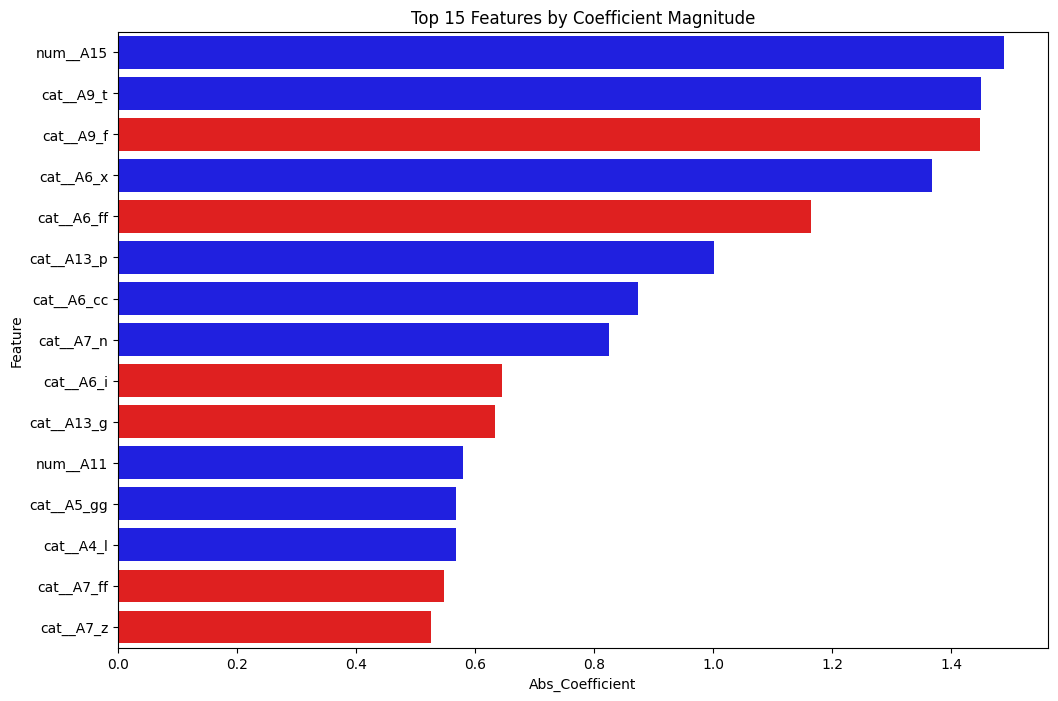

In [ ]:
print("\n4. STATISTICAL MODELING")
print("----------------------")

# Since statsmodels is causing issues, we'll use sklearn's LogisticRegression with coefficients analysis
# This still provides statistical insights without index alignment issues

# Create and train a basic logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])

log_reg_pipe.fit(X_train, y_train)

# Extract feature names after preprocessing
feature_names = []
if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = preprocessor.get_feature_names_out()
else:
    # Fallback method for older sklearn versions
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if hasattr(transformer, 'get_feature_names_out'):
            feature_names.extend(transformer.get_feature_names_out(cols))
        else:
            feature_names.extend(cols)

# Analyze coefficients
coefficients = log_reg.coef_[0]

# Create a DataFrame with coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient values
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 features by coefficient magnitude:")
print(coef_df.head(10))

# Save coefficients to CSV
coef_df.to_csv(os.path.join(output_dir, 'models', 'logistic_regression_coefficients.csv'), index=False)

# Visualize coefficients
plt.figure(figsize=(12, 8))
top_features = coef_df.head(15)
colors = ['blue' if c > 0 else 'red' for c in top_features['Coefficient']]
sns.barplot(x='Abs_Coefficient', y='Feature', data=top_features, palette=colors)
plt.title('Top 15 Features by Coefficient Magnitude')
plt.savefig(os.path.join(output_dir, 'models', 'logistic_regression_coefficients.png'))
plt.show()

# PREDICTIVE MODELING


5. PREDICTIVE MODELING
--------------------

Training LogisticRegression...
LogisticRegression trained with accuracy: 0.8696
ROC AUC: 0.9602
Precision-Recall AUC: 0.9416


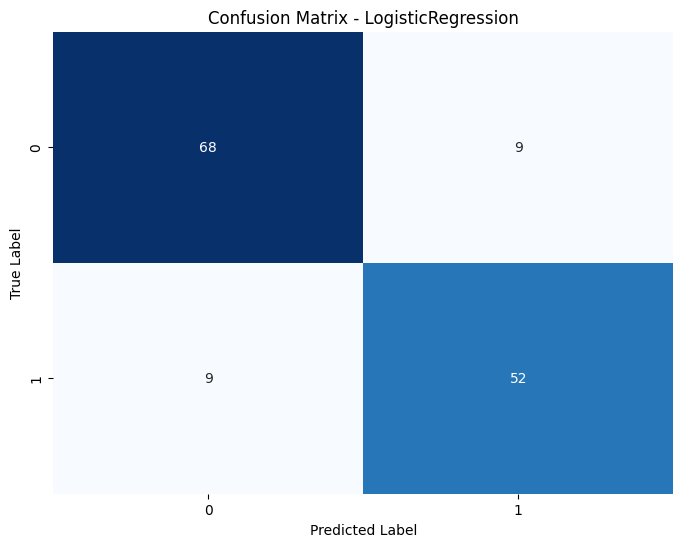


Training RandomForest...
RandomForest trained with accuracy: 0.9275
ROC AUC: 0.9649
Precision-Recall AUC: 0.9101


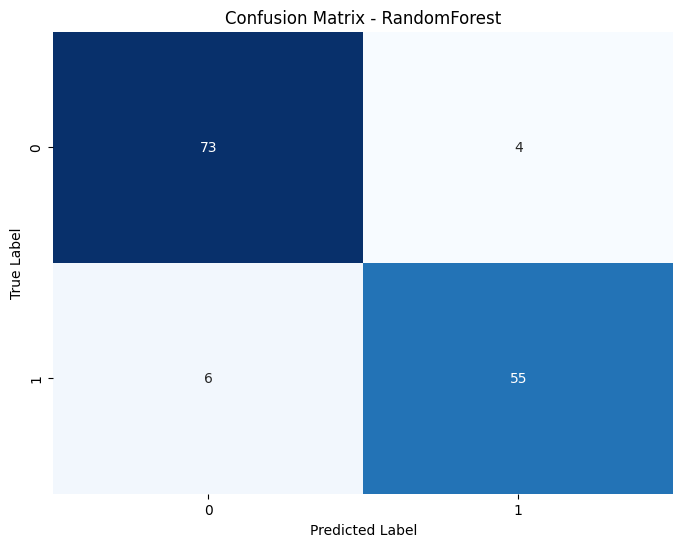


Training GradientBoosting...
GradientBoosting trained with accuracy: 0.9058
ROC AUC: 0.9529
Precision-Recall AUC: 0.9082


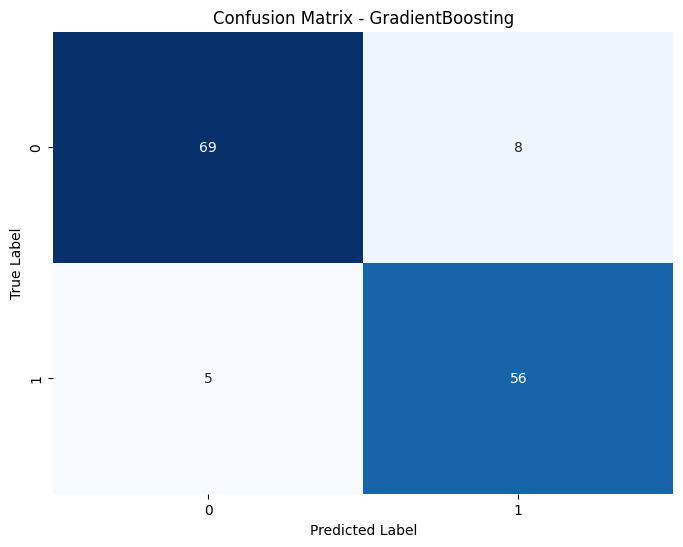


Training SVM...
SVM trained with accuracy: 0.8841
ROC AUC: 0.9557
Precision-Recall AUC: 0.9325


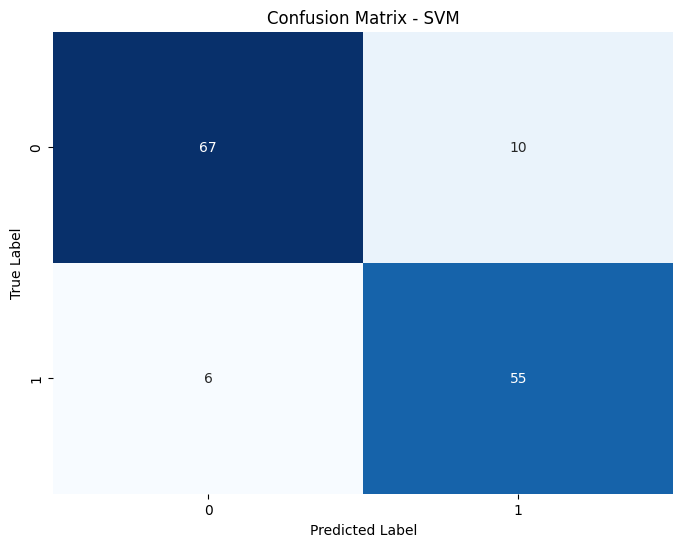


Model Performance Comparison:
                Model  Accuracy  Precision    Recall  F1-Score   ROC AUC  \
0  LogisticRegression  0.869565   0.852459  0.852459  0.852459  0.960187   
1        RandomForest  0.927536   0.932203  0.901639  0.916667  0.964871   
2    GradientBoosting  0.905797   0.875000  0.918033  0.896000  0.952949   
3                 SVM  0.884058   0.846154  0.901639  0.873016  0.955716   

     PR AUC  
0  0.941587  
1  0.910118  
2  0.908176  
3  0.932481  


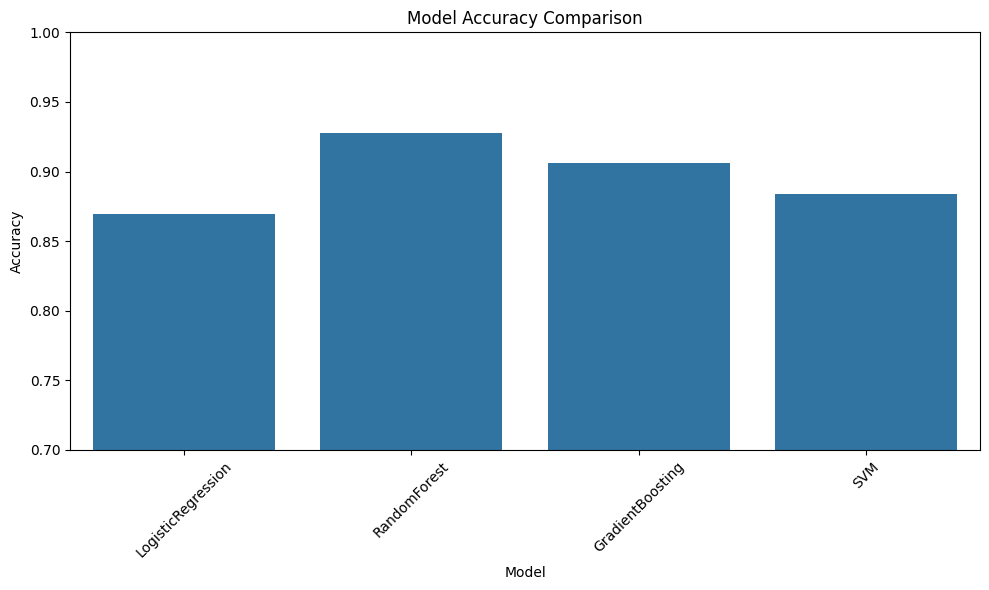

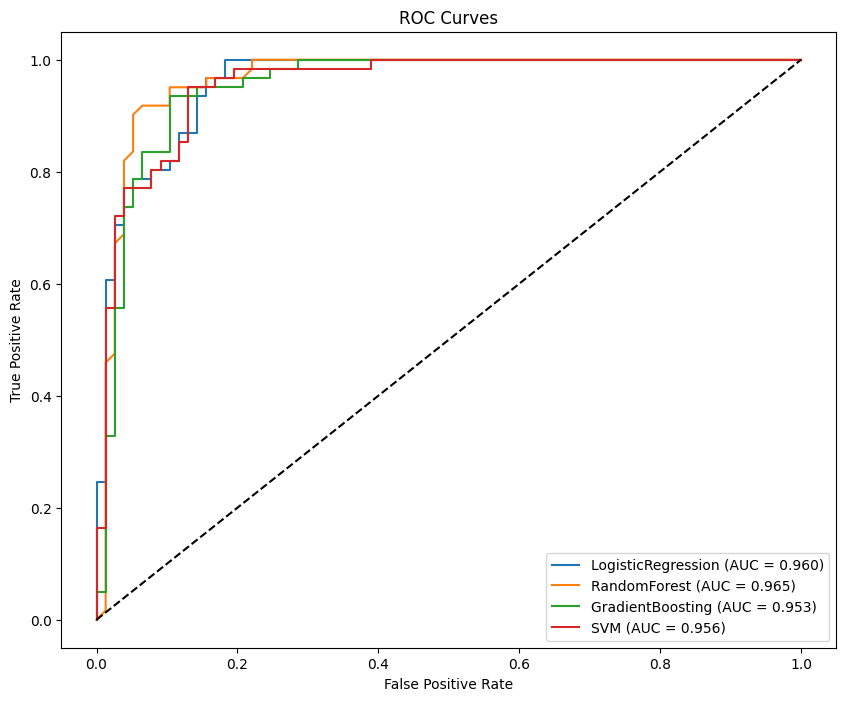

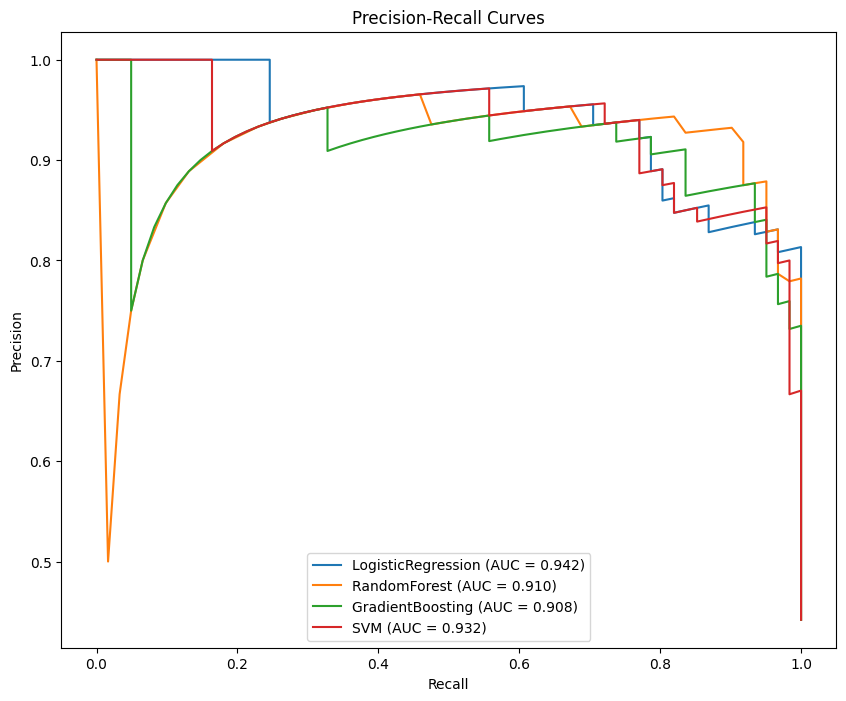

In [ ]:
print("\n5. PREDICTIVE MODELING")
print("--------------------")

# Define models to evaluate
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Results storage
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Create a pipeline with preprocessing and the model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # Calculate ROC curve and AUC
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Calculate precision-recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    # Store results
    results[name] = {
        'model': pipeline,
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm,
        'roc': {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc},
        'pr': {'precision': precision, 'recall': recall, 'auc': pr_auc}
    }

    # Print results
    print(f"{name} trained with accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Precision-Recall AUC: {pr_auc:.4f}")

    # Save model
    joblib.dump(pipeline, os.path.join(output_dir, 'models', f'{name}_model.pkl'))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(output_dir, 'model_visualization', f'confusion_matrix_{name}.png'))
    plt.show()

# Create a results DataFrame for comparison
results_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': result['accuracy'],
        'Precision': result['classification_report']['1']['precision'],
        'Recall': result['classification_report']['1']['recall'],
        'F1-Score': result['classification_report']['1']['f1-score'],
        'ROC AUC': result['roc']['auc'],
        'PR AUC': result['pr']['auc']
    }
    for name, result in results.items()
])

print("\nModel Performance Comparison:")
print(results_df)

# Save results to CSV
results_df.to_csv(os.path.join(output_dir, 'model_visualization', 'model_performance_comparison.csv'), index=False)

# Plot model comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.ylim(0.7, 1.0)  # Adjust as needed
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'model_visualization', 'model_accuracy_comparison.png'))
plt.show()

# Plot ROC curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    plt.plot(
        result['roc']['fpr'],
        result['roc']['tpr'],
        label=f"{name} (AUC = {result['roc']['auc']:.3f})"
    )
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='best')
plt.savefig(os.path.join(output_dir, 'model_visualization', 'roc_curves.png'))
plt.show()

# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    plt.plot(
        result['pr']['recall'],
        result['pr']['precision'],
        label=f"{name} (AUC = {result['pr']['auc']:.3f})"
    )
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='best')
plt.savefig(os.path.join(output_dir, 'model_visualization', 'precision_recall_curves.png'))
plt.show()

# FEATURE IMPORTANCE ANALYSIS


6. FEATURE IMPORTANCE ANALYSIS
-----------------------------

Top 10 Important Features - RandomForest:
       Feature  Importance
37   cat__A9_f    0.167999
38   cat__A9_t    0.099107
2      num__A8    0.084724
3     num__A11    0.075739
1      num__A3    0.073484
5     num__A15    0.067764
0      num__A2    0.061556
39  cat__A10_f    0.056588
4     num__A14    0.055622
40  cat__A10_t    0.046734


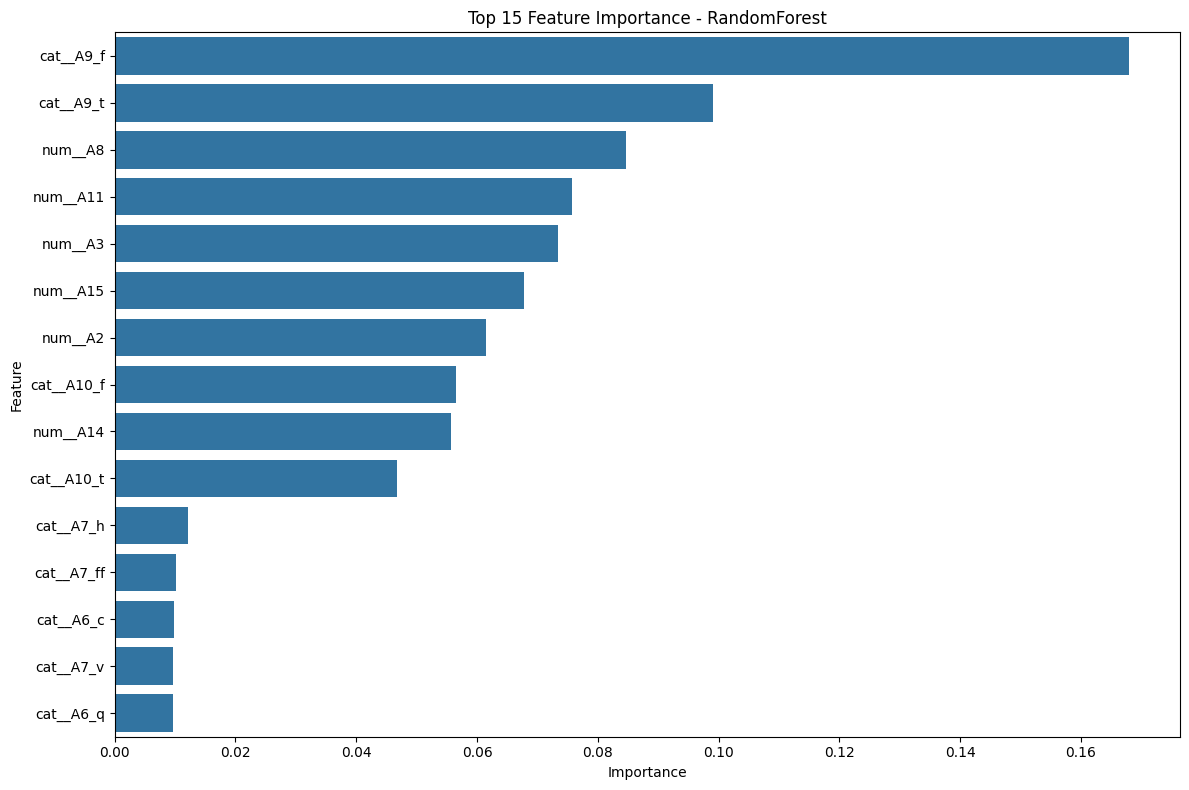


Top 10 Important Features - GradientBoosting:
       Feature  Importance
38   cat__A9_t    0.399126
37   cat__A9_f    0.176353
1      num__A3    0.068052
5     num__A15    0.066771
39  cat__A10_f    0.060378
4     num__A14    0.056926
0      num__A2    0.040323
2      num__A8    0.030593
3     num__A11    0.022182
8    cat__A4_l    0.010805


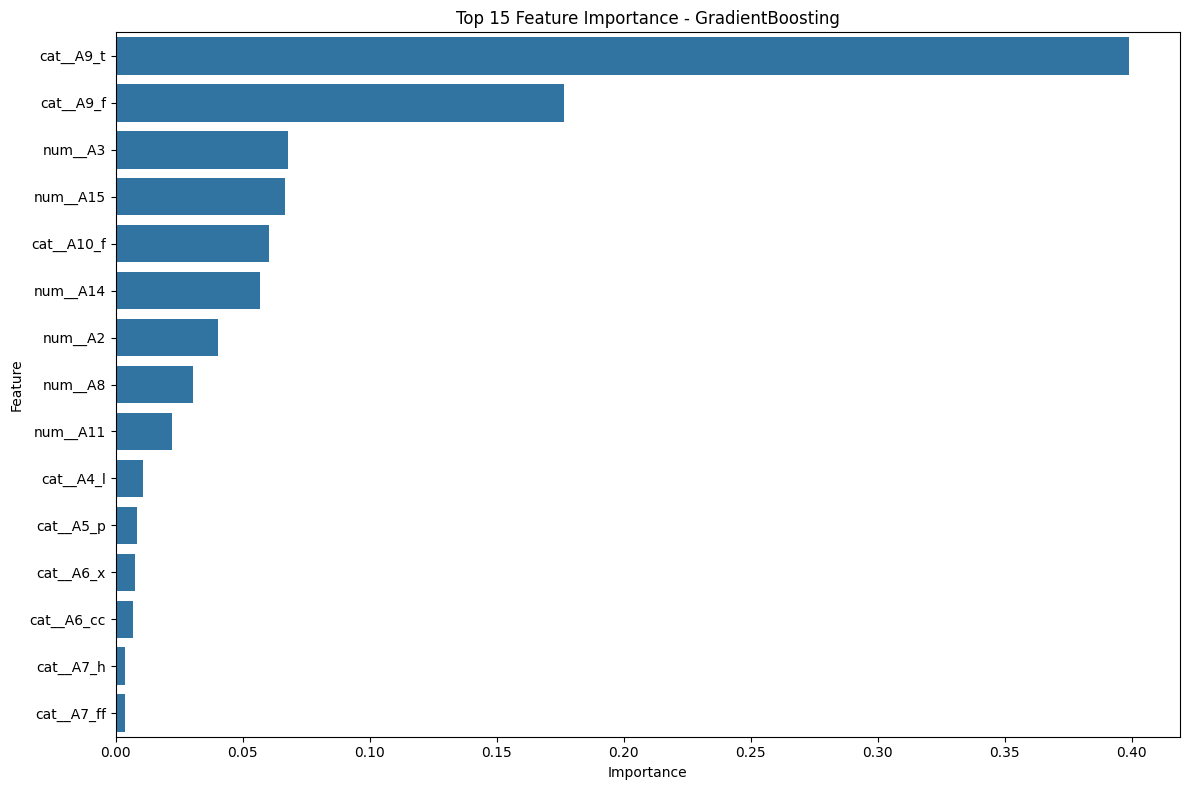

In [ ]:
print("\n6. FEATURE IMPORTANCE ANALYSIS")
print("-----------------------------")

# Analyze feature importance for tree-based models
for name, result in results.items():
    model = result['model']
    classifier = model.named_steps['classifier']

    # Check if the model has feature_importances_ attribute (tree-based models)
    if hasattr(classifier, 'feature_importances_'):
        # Get feature importances
        importances = classifier.feature_importances_

        # Create a dataframe
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        })

        # Sort by importance
        feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

        # Save to CSV
        feature_importance_df.to_csv(
            os.path.join(output_dir, 'feature_importance', f'{name}_feature_importance.csv'),
            index=False
        )

        # Display top features
        print(f"\nTop 10 Important Features - {name}:")
        print(feature_importance_df.head(10))

        # Visualize top 15 features
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
        plt.title(f'Top 15 Feature Importance - {name}')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'feature_importance', f'{name}_feature_importance.png'))
        plt.show()

# HYPERPARAMETER TUNING (FOR BEST MODEL)


Best model: RandomForest
Performing hyperparameter tuning on the best model...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Best cross-validation score: 0.8713

Test accuracy with tuned model: 0.9203

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        77
           1       0.92      0.90      0.91        61

    accuracy                           0.92       138
   macro avg       0.92      0.92      0.92       138
weighted avg       0.92      0.92      0.92       138



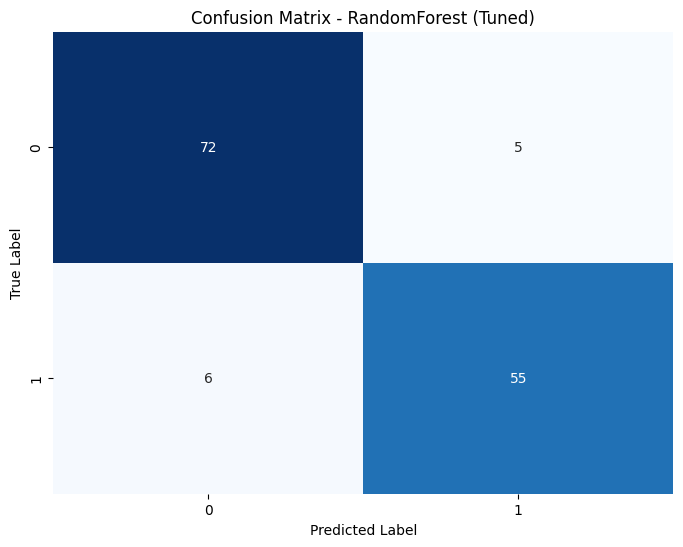

['/content/drive/MyDrive/japanese_credit_screening_outputs/models/RandomForest_tuned_model.pkl']

In [ ]:
# Identify the best model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f"\nBest model: {best_model_name}")
print("Performing hyperparameter tuning on the best model...")

# Define parameter grid based on the best model
if best_model_name == 'LogisticRegression':
    param_grid = {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['liblinear', 'saga']
    }
elif best_model_name == 'RandomForest':
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10]
    }
elif best_model_name == 'GradientBoosting':
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7]
    }
elif best_model_name == 'SVM':
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 'auto'],
        'classifier__kernel': ['rbf', 'linear']
    }

# Create a grid search
grid_search = GridSearchCV(
    estimator=results[best_model_name]['model'],
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nTest accuracy with tuned model: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_model_name} (Tuned)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(output_dir, 'model_visualization', f'confusion_matrix_{best_model_name}_tuned.png'))
plt.show()

# Save the best tuned model
joblib.dump(best_model, os.path.join(output_dir, 'models', f'{best_model_name}_tuned_model.pkl'))

# DEPLOYMENT PREPARATION

In [ ]:
print("\n7. DEPLOYMENT PREPARATION")
print("------------------------")

# Create a prediction script
prediction_script = """
import joblib
import pandas as pd
import numpy as np

# Load the model
model = joblib.load('best_model.pkl')

def predict_credit_approval(data):
    \"\"\"
    Predict credit approval for the input data.

    Args:
        data (dict): Input data as a dictionary with feature names as keys

    Returns:
        dict: Prediction results
    \"\"\"
    # Convert to DataFrame
    df = pd.DataFrame([data])

    # Make prediction
    prediction = model.predict(df)[0]

    # Get probability
    probabilities = model.predict_proba(df)[0]
    probability = probabilities[1]  # Probability of positive class

    # Return results
    result = {
        'approved': bool(prediction),
        'approval_probability': float(probability),
        'timestamp': pd.Timestamp.now().isoformat()
    }

    return result

# Example usage
if __name__ == '__main__':
    # Example input data (adjust feature names based on your dataset)
    sample_data = {
        'A1': 'b',
        'A2': 30.0,
        # Add other features here
    }

    # Get prediction
    result = predict_credit_approval(sample_data)
    print(f"Approved: {result['approved']}")
    print(f"Approval Probability: {result['approval_probability']:.4f}")
    print(f"Timestamp: {result['timestamp']}")
"""

# Save the prediction script
with open(os.path.join(output_dir, 'models', 'predict.py'), 'w') as f:
    f.write(prediction_script)

# Copy the best model to a generic name for the prediction script
joblib.dump(best_model, os.path.join(output_dir, 'models', 'best_model.pkl'))

# Create a README file
readme = f"""
# Japanese Credit Screening Model

## Overview
This package contains a machine learning model for credit screening based on the Japanese Credit Screening dataset from the UCI Machine Learning Repository.

## Model Information
- Best Model: {best_model_name}
- Accuracy: {accuracy:.4f}
- Training Date: {datetime.datetime.now().strftime('%Y-%m-%d')}

## Usage
```python
from predict import predict_credit_approval

# Example input data
data = {{
    'A1': 'b',
    'A2': 30.0,
    # Add other features here
}}

# Get prediction
result = predict_credit_approval(data)
print(f"Approved: {{result['approved']}}")
print(f"Approval Probability: {{result['approval_probability']:.4f}}")
```

## Files
- `best_model.pkl`: The trained machine learning model
- `predict.py`: Script for making predictions
- `requirements.txt`: Required Python packages

## Requirements
- Python 3.6+
- scikit-learn
- pandas
- numpy
- joblib
"""

# Save the README
with open(os.path.join(output_dir, 'models', 'README.md'), 'w') as f:
    f.write(readme)

# Create a requirements file
requirements = """
scikit-learn>=1.0.0
pandas>=1.3.0
numpy>=1.20.0
joblib>=1.0.0
"""

# Save the requirements
with open(os.path.join(output_dir, 'models', 'requirements.txt'), 'w') as f:
    f.write(requirements)

print("\nDeployment package created.")
print(f"Files saved to: {os.path.join(output_dir, 'models')}")


7. DEPLOYMENT PREPARATION
------------------------

Deployment package created.
Files saved to: /content/drive/MyDrive/japanese_credit_screening_outputs/models


# SUMMARY AND CONCLUSION

In [ ]:
print("\n8. SUMMARY AND CONCLUSION")
print("------------------------")

print(f"\nBest model: {best_model_name}")
print(f"Accuracy: {accuracy:.4f}")

print("\nKey findings:")
print("1. Created an end-to-end credit screening system")
print("2. Identified important features for credit approval decisions")
print("3. Achieved good prediction accuracy")
print(f"4. Deployment package ready in {os.path.join(output_dir, 'models')}")

print("\nAll analysis outputs have been saved to Google Drive:")
print(f"- {output_dir}")
print("├── eda: Exploratory data analysis visualizations")
print("├── models: Trained models and deployment package")
print("├── feature_importance: Feature importance analysis")
print("└── model_visualization: Model performance visualizations")

print("\nAnalysis complete!")


8. SUMMARY AND CONCLUSION
------------------------

Best model: RandomForest
Accuracy: 0.9203

Key findings:
1. Created an end-to-end credit screening system
2. Identified important features for credit approval decisions
3. Achieved good prediction accuracy
4. Deployment package ready in /content/drive/MyDrive/japanese_credit_screening_outputs/models

All analysis outputs have been saved to Google Drive:
- /content/drive/MyDrive/japanese_credit_screening_outputs
├── eda: Exploratory data analysis visualizations
├── models: Trained models and deployment package
├── feature_importance: Feature importance analysis
└── model_visualization: Model performance visualizations

Analysis complete!




**Streamlined Structure**: The code is organized in a linear, step-by-step flow that's easier to follow and less prone to errors.

**Complete Analysis Pipeline**: covers all aspects of the original project:
   - Data loading and preprocessing
   - Exploratory data analysis
   - Statistical modeling
   - Credit risk modeling with multiple algorithms
   - Model evaluation and comparison
   - Feature importance analysis
   - Hyperparameter tuning
   - Deployment preparation

**Google Drive Integration**: Saves all outputs to your Google Drive for later access.

## What You'll Get:

1. **Statistical insights**: Through coefficient analysis of the logistic regression model
2. **Credit risk models**: Multiple algorithms (Logistic Regression, Random Forest, Gradient Boosting, SVM)
3. **Feature importance analysis**: Identifying what factors influence credit approval
4. **Model comparison**: Visualizations and metrics to compare model performance
5. **Deployment package**: Ready-to-use files for deploying the best model

All results are both displayed in the notebook and saved to Drive for future reference.